In [1]:
from runtime_support import (
    setup_client_from_env,
    build_fleet_object,
    )

import asyncio

from openapi_client.api.fleet_api import FleetApi
from openapi_client.api.agents_api import AgentsApi
from openapi_client.api.systems_api import SystemsApi

with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        agents_api = AgentsApi(client)
        systems_api = SystemsApi(client)

from core_helpers import (load_initial_fleet_state,
                          init_world_state,
                          load_initial_waypoint_state,
                          get_wps_by_trait,
                          all_wp_visitor,
                          api_navigate_ship,
                          api_get_ship_nav,
                          plot_route_svg,
                          patrol_markets,
                          patrol_shipyards
                          )


#-------- write fleet activity and fleet specifications to db -------------
state = await load_initial_fleet_state(fleet_api)

#-------- write waypoint reference data and traits specifications to db and local objects -------------
wp_refs, wp_traits = await load_initial_waypoint_state(agents_api, systems_api)
print(f"Persisted {len(wp_refs)} waypoint refs and {len(wp_traits)} traits.")

# --------- create locally persisting objects for fleet and world states -------------------
ships_activity_obj = await build_fleet_object(fleet_api)
world_state = await init_world_state(fleet_api, agents_api, systems_api)

# --------- define ship roles -----------

# Extract symbol for a given role
def get_symbol_by_role(ships_dict, role):
    for ship in ships_dict.values():
        if ship.role == role:
            return ship.symbol
    return None

# manually assign ship names by role
command_ship = get_symbol_by_role(state.specs, "COMMAND")
satellite = get_symbol_by_role(state.specs, "SATELLITE")


# ---------- get market waypoints from world state ----------
# all traits of every waypoint
traits_list = world_state.traits.by_wp
# selecting MARKETPLACE trait-bearing waypoints only
markets_df = await get_wps_by_trait(traits_list, "MARKETPLACE")

shipyards_df = await get_wps_by_trait(traits_list, "SHIPYARD")
print(shipyards_df)


Persisted 84 waypoint refs and 237 traits.
[BOOT] Adapted 2 ships into fleet_object
      waypoint    x    y    distance
0   X1-BP71-A2   21  -11   23.706539
1  X1-BP71-H49   34   28   44.045431
2  X1-BP71-C39 -102  117  155.219200


X1-BP71-H49
   visit_idx     waypoint    x    y  leg_distance  cumulative_distance
0          0   X1-BP71-A2   21  -11         0.000                0.000
1          1  X1-BP71-H49   34   28        41.110               41.110
2          2  X1-BP71-C39 -102  117       162.533              203.643
3          3   X1-BP71-A2   21  -11       177.519              381.162
Total travel distance: 381.162
Saved SVG -> markets_route.svg


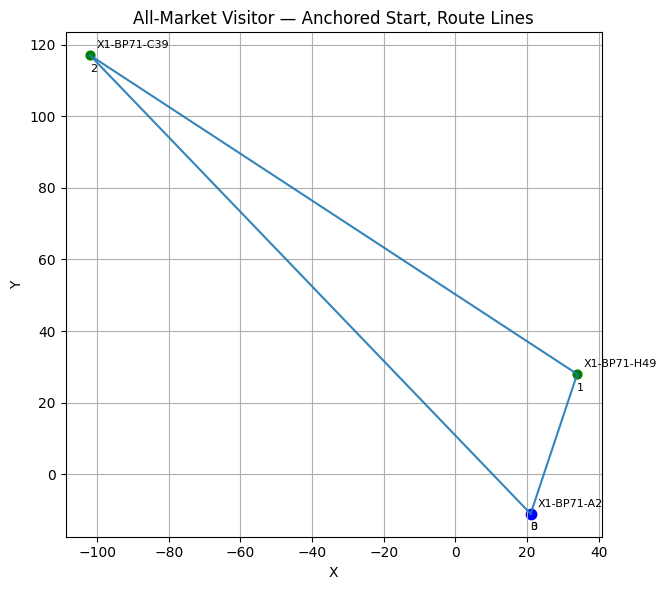

In [2]:

# from selected ships' starting waypoint, draw a route that will visit all market waypoints

nav_resp = await api_get_ship_nav(fleet_api, satellite)

print(nav_resp.waypoint_symbol)
if __name__ == "__main__":
    
    start = shipyards_df.iloc[0,0]

    route = all_wp_visitor(
        shipyards_df,
        start_waypoint=start,
        return_to_start=True,   # set True to draw a loop back to start
        improve_2opt=True,
        fix_start_anchor=True,   # keep chosen start as first
    )

    print(route)
    print("Total travel distance:", route["cumulative_distance"].iloc[-1])

    plot_route_svg(
        markets_df=shipyards_df,
        route_df=route,
        start_waypoint=start,
        svg_path="markets_route.svg",
    )
# ---------- run ----------
async def main():
    patroller = asyncio.create_task(patrol_shipyards(satellite, route))
    #patroller2 = asyncio.create_task(patrol_markets(command_ship, route))
    await asyncio.gather(patroller)

In [ ]:

# await api_navigate_ship(fleet_api, ship_symbol, wp)
await main()

['X1-BP71-A2', 'X1-BP71-H49', 'X1-BP71-C39']
[PATROL] BANGO-2 looping through 3 shipyards.
[PATROL] -> Navigating to X1-BP71-A2 (#1/3)
starting navigation...
[BOOT] Adapted 2 ships into fleet_object
Not at destination, continuing
Not in orbit, going into orbit now...
Prep complete
BANGO-2  has taken off and is in transit
[BOOT] Adapted 2 ships into fleet_object
Seconds until arrival: 127.048222
Arrived and ready
[Shipyard] Capturing X1-BP71-A2 …
[PATROL] -> Navigating to X1-BP71-H49 (#2/3)
starting navigation...
[BOOT] Adapted 2 ships into fleet_object
Not at destination, continuing
Prep complete
BANGO-2  has taken off and is in transit
[BOOT] Adapted 2 ships into fleet_object
Seconds until arrival: 127.730463
Arrived and ready
[Shipyard] Capturing X1-BP71-H49 …
[PATROL] -> Navigating to X1-BP71-C39 (#3/3)
starting navigation...
[BOOT] Adapted 2 ships into fleet_object
Not at destination, continuing
Prep complete
BANGO-2  has taken off and is in transit
[BOOT] Adapted 2 ships into flee

In [ ]:

"""
import asyncio
from core_helpers import build_nodes_from_traits_dict
from refuel_routing import plan_route_and_refuel
from typing import Tuple

async def long_dist_travel(cur_wp, dest_wp, trav_dist, max_trav_dist):

    with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        agents_api = AgentsApi(client)
        systems_api = SystemsApi(client)

    world_state =  await init_world_state(fleet_api, agents_api, systems_api)
    wps = world_state.traits.by_wp
    nodes = build_nodes_from_traits_dict(wps)
    route_plan = plan_route_and_refuel(nodes, cur_wp, dest_wp, trav_dist, 1, 1000, max_trav_dist, 100, 0, 10, 0)
    plan_route_and_refuel()
    refuel_route = route_plan["path"]
    
    return(refuel_route)

#world_state.traits.by_wp


# test whether a waypoint is out of reach for a ships' fuel tank

from runtime_support import (
    setup_client_from_env,
    build_fleet_object,
    )

import asyncio

from openapi_client.api.fleet_api import FleetApi
from openapi_client.api.agents_api import AgentsApi
from openapi_client.api.systems_api import SystemsApi

with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        agents_api = AgentsApi(client)
        systems_api = SystemsApi(client)

from core_helpers import (load_initial_fleet_state,
                          init_world_state,
                          load_initial_waypoint_state,
                          get_wps_by_trait,
                          all_market_visitor,
                          api_get_ship_nav,
                          plot_route_svg,
                          patrol_markets,
                          api_navigate_ship
                          )


async def travel_checker(ship_symbol: str, waypoint_symbol: str):

    with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        systems_api = SystemsApi(client)
        agents_api = AgentsApi(client)

    world_state =  await init_world_state(fleet_api, agents_api, systems_api)

    ships = await build_fleet_object(fleet_api)
    trav_dist = ships.by_symbol[ship_symbol].fuel_current
    max_trav_dist = ships.by_symbol[ship_symbol].fuel_capacity
    cur_wp = ships.by_symbol[ship_symbol].current_waypoint

    cur_x = world_state.waypoints.by_symbol[cur_wp].x
    cur_y = world_state.waypoints.by_symbol[cur_wp].y

    dest = waypoint_symbol

    dest_x = world_state.waypoints.by_symbol[dest].x
    dest_y = world_state.waypoints.by_symbol[dest].y

    x_len = cur_x - dest_x

    y_len = cur_y - dest_y

    import math

    hypo = math.hypot(x_len, y_len)
    print("Distance between coords: ", hypo)

    if hypo > trav_dist:
        # apply routefinder to calculate best route with refuels between distant points
        print("Destination too far, initiating hops")
        route = await long_dist_travel(cur_wp, dest, trav_dist, max_trav_dist)

        for rt in route:
            await api_navigate_ship(fleet_api, ship_symbol, rt)

        return
    else:
         await api_navigate_ship(fleet_api, ship_symbol, waypoint_symbol)


#world_state.waypoints.by_symbol

"""
